In [1]:
import numpy as np
import random
import matplotlib.pyplot as plt

In [5]:
class Config:
    price = 100
    drift = 0
    vol = 0.3
    dt = 0.1
    
    poisson_lambda = 2
    toxicity = 0.2
    persistence = 0.6
    
    tick = 0.01
    spread = 0.02
    quote_size = 1
    impact = np.random.normal(0.01, 0.005)
    
    time_step = 0.1
    
    total_time = 1000
    
class Market:
    def __init__(self, config):
        self.mid = config.price
        self.drift = config.drift
        self.vol = config.vol
        self.dt = config.dt
        
    def update_price(self, external_noise = None):
        if external_noise is None:
            noise = np.random.normal()
        else:
            noise = external_noise
        self.mid += (self.drift*self.dt + self.vol*np.sqrt(self.dt)*noise)
        return self.mid
    
class Order_Flow:
    def __init__(self, config):
        self.poisson_lambda = config.poisson_lambda
        self.dt = config.dt
        self.toxicity = config.toxicity
        self.persistence = config.persistence
        self.last_side = np.random.choice(['buy', 'sell'])
        
    def generate(self, future_noise):
        prob = self.poisson_lambda*self.dt
        
        if np.random.rand() < prob:
            is_toxic = np.random.rand() < self.toxicity
            if is_toxic:
                side = 'buy' if future_noise > 0 else 'sell'
            else:
                if np.random.rand() < self.persistence:
                    side = self.last_side
                else:
                    side = 'sell' if self.last_side == 'buy' else 'buy'
        else:
            return None
        self.last_side = side    
        return {"side": side, "is_toxic": is_toxic}
    
class Market_Maker:
    def __init__(self, config):
        self.spread = config.spread
        self.size = config.quote_size
        self.impact = config.impact
        self.tick = config.tick

        self.inventory = 0
        self.cash = 0
        self.gamma = 0.01
        
        self.spread_pnl = 0
        self.adverse_pnl = 0

    def quote(self, mid, toxicity):
        dynamic_spread = self.spread + 0.05*toxicity
        skewed_mid = mid - (self.inventory * self.gamma)

        bid = np.floor((skewed_mid - dynamic_spread/2)/self.tick)*self.tick
        ask = np.ceil((skewed_mid + dynamic_spread/2)/self.tick)*self.tick
        return bid, ask

    def execute_trade(self, side, bid, ask, mid):

        if side == "buy":

            # trader lifts our ask
            self.inventory -= 1
            self.cash += ask
            self.spread_pnl += (ask - mid)

        elif side == "sell":

            # trader hits our bid
            self.inventory += 1
            self.cash -= bid
            self.spread_pnl += (mid - bid)
    
class Simulator:
    def __init__(self, config, market, flow, mm):
        self.config = config
        self.market = market
        self.flow = flow
        self.mm = mm

        self.time = 0
        
    def graph_plotting(self, price, inven, history, spread_history, adverse_history, inventory_history):
        plt.figure(figsize=(10, 8))
        
        #Price
        plt.subplot(3,1,1)
        plt.plot(price, alpha=0.5)
        plt.axhline(y=100, color='green', linestyle='--', alpha=0.5, label='Start Price')
        plt.title("Market Making Mid-Price Simulation (Arithmetic)")
        plt.xlabel("Time Steps")
        plt.ylabel("Price")
        
        #PnL
        plt.subplot(3,1,2)
        plt.plot(history, label="Total PnL", color='green', alpha = 0.5)
        plt.plot(spread_history, label="Spread", alpha = 0.5)
        plt.plot(adverse_history, label="Adverse", alpha = 0.5)
        plt.legend()
        plt.title('PnL Decomposition')
        
        #Invertory
        plt.subplot(3,1,3)
        plt.plot(inven, color='blue', alpha=0.5)
        plt.title('Inventory')
        
        plt.tight_layout()
        plt.show()
        
        #Summary
        residual = history[-1] - spread_history[-1] - adverse_history[-1]
        print("========================== PnL Breakdown ==========================")
        print(f"Spread PnL: {spread_history[-1]:.4f}")
        print(f"Adverse Selection: {adverse_history[-1]:.4f}")
        print(f"Inventory Exposure: {residual:.4f}")
        print(f"Total PnL: {history[-1]:.4f}")
        
    def run(self):
        current_mid = config.price
        price = [current_mid]
        history = []
        inven = []
        inventory_history = []
        spread_history = []
        adverse_history = []
        
        while self.time < self.config.total_time:
            future_noise = np.random.normal()
            mid = self.market.update_price(future_noise)
            
            bid, ask = self.mm.quote(mid, self.flow.toxicity)
            order = self.flow.generate(future_noise)
            
            if order is not None:
                side = order['side']
                distance = abs(ask - mid) if side == 'buy' else abs(bid - mid)

                k = 20.0 # 敏感度參數
                fill_prob = np.exp(-k * distance)

                if np.random.rand() < fill_prob:
                    old_inventory = self.mm.inventory
                    old_mid = self.market.mid
                    side = order['side']
                    self.mm.execute_trade(side, bid, ask, mid)
                    
                    impact_dir = 1 if side == 'buy' else -1
                    #Toxic Impact
                    if order['is_toxic']:
                        self.market.mid += impact_dir * self.mm.impact #Informed trades generate permanet price impact
                        new_mid = self.market.mid
                        price_move = new_mid - old_mid
                        
                        if side == 'buy':
                            self.mm.adverse_pnl -= price_move
                        else:
                            self.mm.adverse_pnl += price_move
                    else:
                        self.market.mid += impact_dir * np.random.normal(0, 0.002)
                else:
                    pass

            # 5. PnL (Mark-to-Market)
            
            pnl = self.mm.cash + self.mm.inventory * self.market.mid
            history.append(pnl)
            inven.append(self.mm.inventory)
            price.append(self.market.mid)
            spread_history.append(self.mm.spread_pnl)
            adverse_history.append(self.mm.adverse_pnl)
            
            self.time += self.config.time_step
            
        self.graph_plotting(price, inven, history, spread_history, adverse_history, inventory_history)

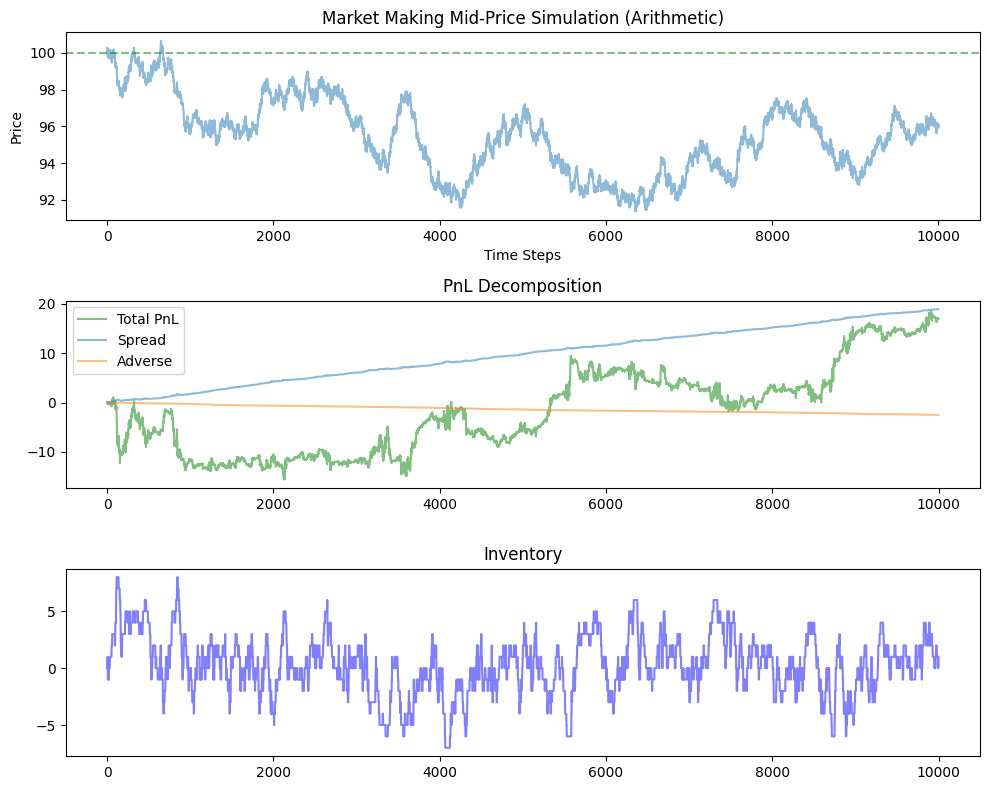

========================== PnL Breakdown ==========================
Spread PnL: 18.9299
Adverse Selection: -2.5179
Inventory Exposure: 0.4741
Total PnL: 16.8861


In [4]:
config = Config()

market = Market(config)
flow = Order_Flow(config)
mm = Market_Maker(config)

sim = Simulator(config, market, flow, mm)

sim.run()